In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


# Nigeria Climate Data - Exploratory Data Analysis

## Overview
This notebook analyzes daily climate data for Nigeria from 2015 to 2026.
The data comes from NASA POWER satellite measurements recorded at Abuja.

The goal is to clean the data, explore temperature and rainfall trends,
and extract insights that can support Ethiopia's position at COP32.

In [2]:
df = pd.read_csv("../data/Nigeria.csv")
df["Country"] = "Nigeria"
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month

print("Shape:", df.shape)
df.head()

Shape: (4108, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


## Data Loading
Nigeria dataset contains 4108 daily observations recorded at Abuja
from January 2015 to March 2026. It has 12 columns covering temperature,
rainfall, humidity, wind speed, pressure and specific humidity.
Each row represents one day of climate measurements.

In [3]:
df.replace(-999, np.nan, inplace=True)

duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)
df.drop_duplicates(inplace=True)

missing = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

print("\nMissing values per column:")
print(pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent.round(2)}))

Number of duplicate rows: 0

Missing values per column:
             Missing Count  Missing %
YEAR                     0        0.0
DOY                      0        0.0
T2M                      0        0.0
T2M_MAX                  0        0.0
T2M_MIN                  0        0.0
T2M_RANGE                0        0.0
PRECTOTCORR              0        0.0
RH2M                     0        0.0
WS2M                     0        0.0
WS2M_MAX                 0        0.0
PS                       0        0.0
QV2M                     0        0.0
Country                  0        0.0
Date                     0        0.0
Month                    0        0.0


## Data Cleaning
After replacing NASA's missing value code (-999) with NaN,
the Nigeria dataset showed no missing values in any column.
No duplicate rows were found either.
All 4108 daily records are usable without any data loss.

In [4]:
df.describe().round(2)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108,4108.00
mean,2020.13,180.12,26.66,28.91,24.89,4.03,4.21,85.24,2.22,2.90,100.83,18.56,2020-08-15 12:00:00,6.42
min,2015.00,1.00,21.12,25.26,15.17,1.16,0.00,54.40,0.74,1.29,100.38,9.43,2015-01-01 00:00:00,1.00
25%,2017.00,86.00,25.72,27.92,24.10,3.09,0.33,83.93,1.77,2.37,100.71,17.97,2017-10-23 18:00:00,3.00
50%,2020.00,179.00,26.82,28.99,25.10,3.77,1.84,86.35,2.20,2.81,100.82,18.84,2020-08-15 12:00:00,6.00
75%,2023.00,272.00,27.54,29.91,25.86,4.60,5.20,88.50,2.63,3.39,100.95,19.57,2023-06-08 06:00:00,9.00
max,2026.00,366.00,29.29,32.88,27.79,11.73,166.10,93.79,4.78,6.00,101.35,21.74,2026-03-31 00:00:00,12.00
std,3.25,106.29,1.12,1.29,1.40,1.40,7.27,5.45,0.59,0.70,0.17,1.65,NaN,3.48


## Summary Statistics
Nigeria has a mean temperature of 26.66°C and very high humidity 
of 85.24% — the highest humidity of all 5 countries analyzed.
The maximum rainfall of 166.10mm is also the highest single day 
rainfall across all countries showing Nigeria experiences the most 
intense tropical rain events.
Minimum humidity of 54.40% confirms Nigeria remains humid even 
during its driest periods.

In [5]:
columns_to_check = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
z_scores = df[columns_to_check].apply(stats.zscore)
outlier_mask = (z_scores.abs() > 3)
outlier_count = outlier_mask.any(axis=1).sum()

print("Total outlier rows detected:", outlier_count)
print("\nOutliers per column:")
print(outlier_mask.sum())

Total outlier rows detected: 225

Outliers per column:
T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
WS2M_MAX        10
dtype: int64


## Outlier Detection
225 outlier rows detected — the highest across all 5 countries.
RH2M (humidity) has 128 outliers showing Nigeria experiences 
frequent unusual humidity conditions.
PRECTOTCORR has 75 outliers representing extreme rainfall events.
Decision: Keep all outliers as they represent real extreme weather
events important for climate analysis..

In [12]:
# Forward fill missing values for weather variables
weather_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE", 
                "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

df[weather_cols] = df[weather_cols].ffill()

# Check no missing values remain
print("Missing values after forward fill:")
print(df[weather_cols].isna().sum())

Missing values after forward fill:
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
dtype: int64


## Missing Value Treatment
Forward-fill was applied to all weather variables after outlier detection.
Since Nigeria had zero missing values, no changes were made to the data.
Forward-fill ensures that if any missing values existed they would be 
filled with the most recent valid observation which is appropriate for 
continuous daily weather measurements.

In [6]:
df.to_csv("../data/nigeria_clean.csv", index=False)
print("Cleaned data saved")

Cleaned data saved


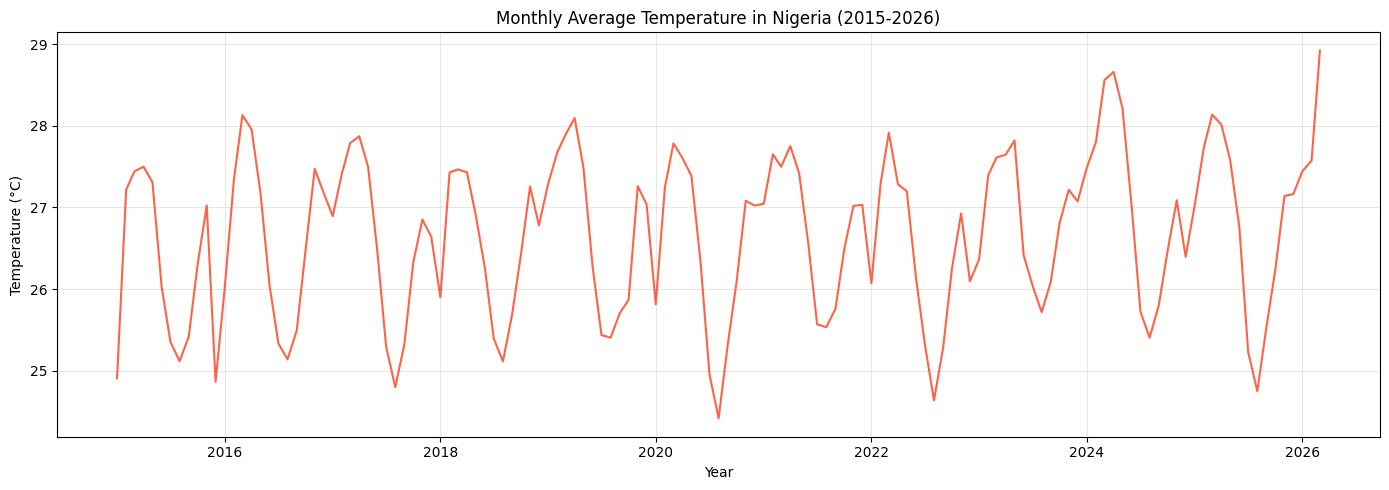

In [7]:
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(monthly_temp[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp["Date"], monthly_temp["T2M"], color="tomato", linewidth=1.5)
plt.title("Monthly Average Temperature in Nigeria (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Temperature Trend (2015-2026)
Nigeria shows a warm tropical temperature pattern with mean of 26.66°C.

Key observations:
- Temperature follows a seasonal cycle influenced by rainfall patterns
- Cooler periods coincide with the main rainy season April to October
- A gradual warming trend is visible over the 11 year period
- Nigeria has the smallest temperature range of all 5 countries 
  showing a very stable tropical climate
- Rising temperatures threaten agriculture and water security for 
  Nigeria's large population

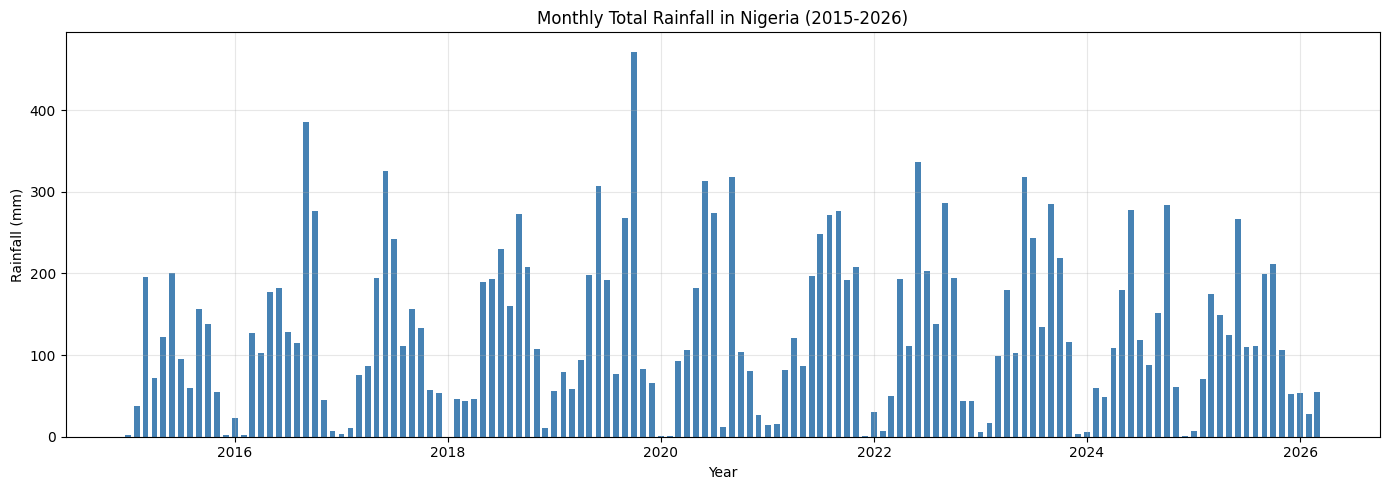

In [8]:
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
monthly_rain["Date"] = pd.to_datetime(monthly_rain[["YEAR", "Month"]].assign(DAY=1))

plt.figure(figsize=(14, 5))
plt.bar(monthly_rain["Date"], monthly_rain["PRECTOTCORR"], color="steelblue", width=20)
plt.title("Monthly Total Rainfall in Nigeria (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rainfall Trend (2015-2026)
Nigeria receives the highest rainfall of all 5 countries with a 
maximum single day rainfall of 166.10mm.

Key observations:
- Clear rainy season visible each year from April to October
- Dry season from November to March with very little rainfall
- High variability between years showing climate instability
- Extreme rainfall spikes visible representing serious flood risk
- Nigeria's large population makes it highly vulnerable to 
  flooding and drought caused by irregular rainfall patterns

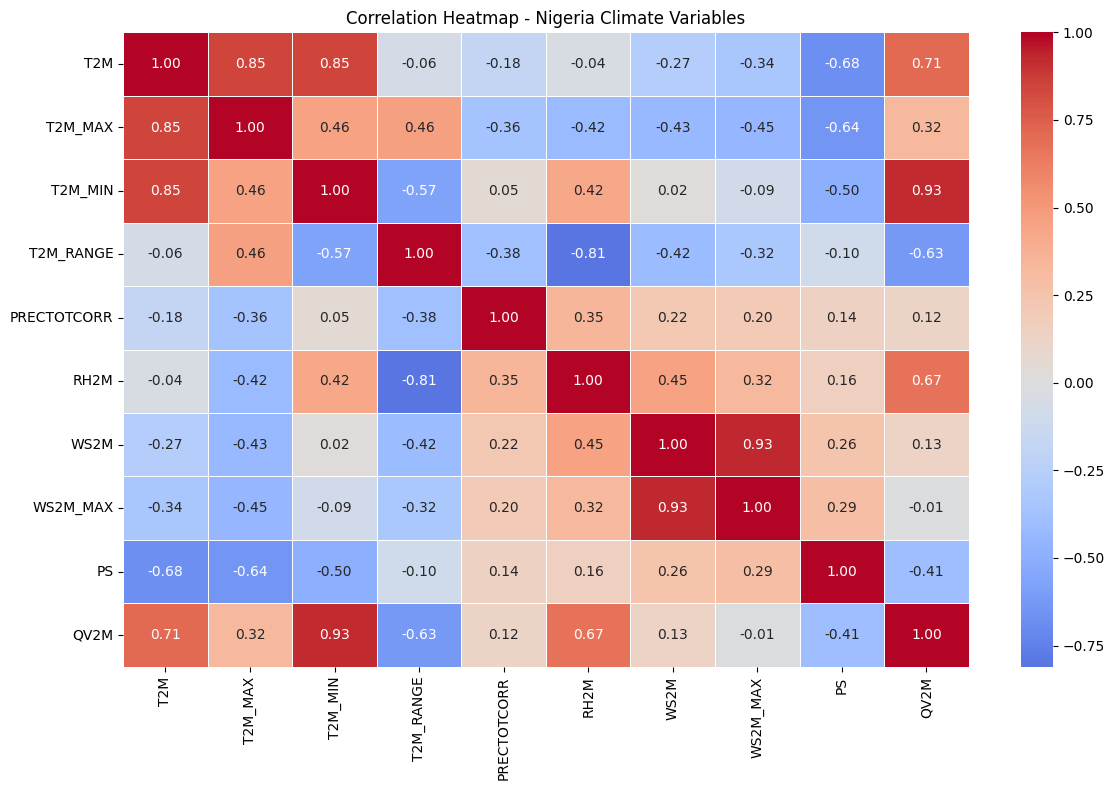

In [9]:
numeric_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE", 
                "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap - Nigeria Climate Variables")
plt.tight_layout()
plt.show()

## Correlation Analysis
Key correlations found in Nigeria:

1. T2M and QV2M - strong positive correlation. Warmer air holds
   more moisture in Nigeria's tropical climate confirming high 
   humidity levels throughout the year.
2. T2M and RH2M - negative correlation. Higher temperatures
   reduce relative humidity even in tropical conditions.
3. T2M_MAX and T2M_MIN - strong positive correlation showing
   consistent warming patterns across day and night.

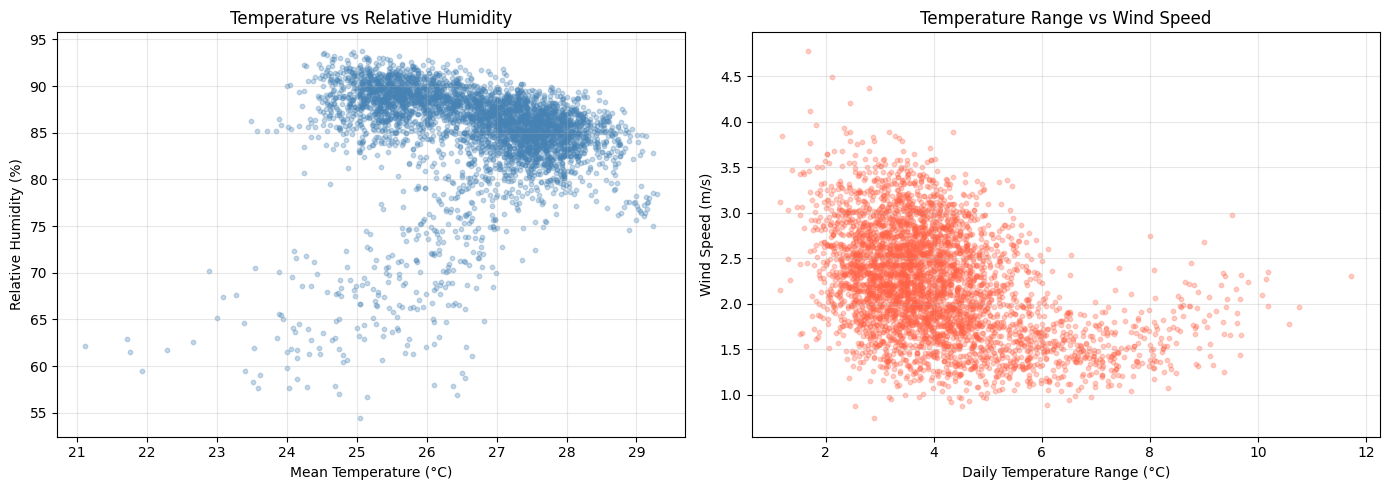

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["T2M"], df["RH2M"], alpha=0.3, color="steelblue", s=10)
axes[0].set_title("Temperature vs Relative Humidity")
axes[0].set_xlabel("Mean Temperature (°C)")
axes[0].set_ylabel("Relative Humidity (%)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df["T2M_RANGE"], df["WS2M"], alpha=0.3, color="tomato", s=10)
axes[1].set_title("Temperature Range vs Wind Speed")
axes[1].set_xlabel("Daily Temperature Range (°C)")
axes[1].set_ylabel("Wind Speed (m/s)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Scatter Plot Analysis

Plot 1 - Temperature vs Relative Humidity:
Nigeria shows the highest humidity levels of all 5 countries with 
most points clustered above 80% humidity. Even at higher temperatures 
humidity remains very elevated confirming Nigeria's tropical climate.

Plot 2 - Temperature Range vs Wind Speed:
Nigeria has the smallest daily temperature ranges of all countries 
analyzed. This reflects the stabilizing effect of high humidity and 
cloud cover in tropical climates reducing temperature swings between 
day and night.

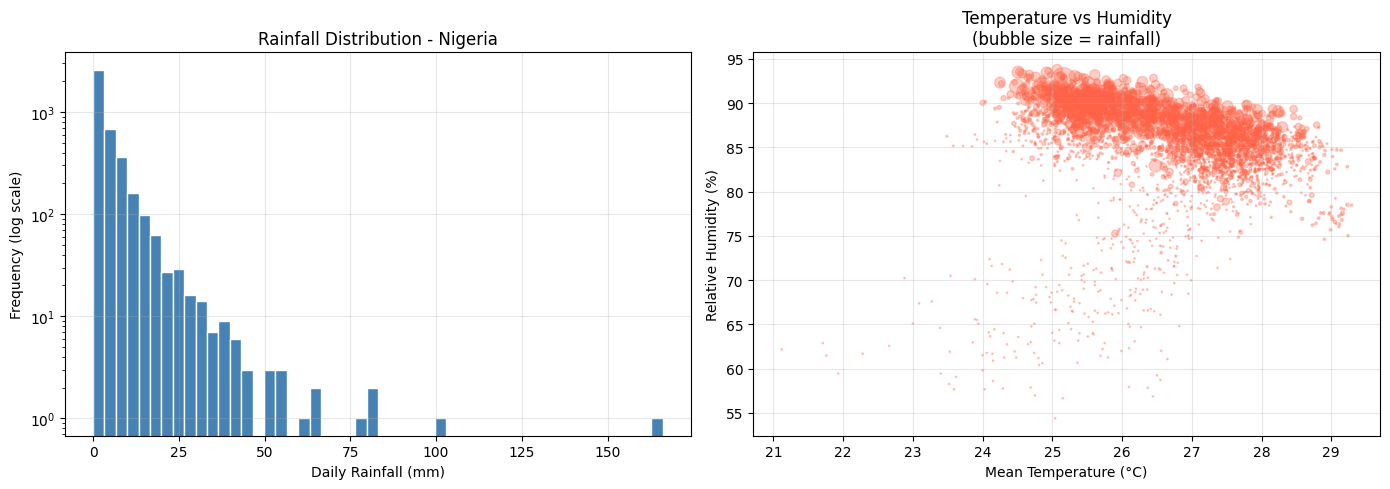

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["PRECTOTCORR"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Rainfall Distribution - Nigeria")
axes[0].set_xlabel("Daily Rainfall (mm)")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"] * 2 + 1, alpha=0.3, color="tomato")
axes[1].set_title("Temperature vs Humidity\n(bubble size = rainfall)")
axes[1].set_xlabel("Mean Temperature (°C)")
axes[1].set_ylabel("Relative Humidity (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()